# Seller Segmentation in an E-Commerce Marketplace

## Project Overview

Seller segmentation is a key business analytics technique that enables e-commerce platforms to better understand seller behavior and optimize marketplace performance.

In this project, sellers are grouped into meaningful segments using **feature engineering** and **K-Means clustering**. The resulting segments help identify different seller profiles based on product activity, pricing strategy, conversion performance, and product diversity.

The analysis provides actionable insights that can support seller management, marketing strategies, and platform growth.

---

## Objectives

- Analyze seller behavior using transactional data
- Engineer meaningful seller-level features
- Cluster sellers based on business characteristics
- Profile each seller segment
- Provide actionable business recommendations

# Business Problem

E-commerce marketplaces often have thousands of sellers with different business behaviors and performance levels.

Treating every seller the same can lead to inefficient marketing efforts, poor seller support, and missed business opportunities.

The objective of this project is to identify distinct seller groups based on their marketplace performance.

The resulting seller segments can help answer questions such as:

- Which sellers generate the highest value?
- Which sellers need support to improve performance?
- Which sellers have growth potential?
- Which sellers may require retention strategies?

These insights enable more data-driven business decisions for marketplace management.

### Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

### Load Dataset

In [2]:
# Load dataset
df = pd.read_excel("../data/sample_sales.xlsx")

# Display the first five rows
df.head()

,Variant ID,Product ID,Product Status,Category,Seller ID,Seller Type,Conversion Rate in Last 30 Days,Price Before Discount,Price After Discount
0,38832443,10712965,Active,BT,203163,Normal,NaN,1.215000e+06,445500.004054
1,37351587,10404813,Active,AC,908351,Normal,NaN,6.885000e+05,243000.002211
2,37355516,10406614,Active,AC,908351,Normal,NaN,6.885000e+05,243000.002211
3,37928221,10555987,Active,AC,908351,Normal,NaN,1.620000e+06,810000.007371
4,37931881,10563472,Active,AC,908351,Normal,NaN,1.620000e+06,810000.007371


### Dataset Shape

In [3]:
print(f"Number of rows: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 2,999
Number of columns: 9


### Dataset Information

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2999 entries, 0 to 2998
Data columns (total 9 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Variant ID                       2999 non-null   int64  
 1   Product ID                       2999 non-null   int64  
 2   Product Status                   2999 non-null   object 
 3   Category                         2999 non-null   object 
 4   Seller ID                        2999 non-null   int64  
 5   Seller Type                      2999 non-null   object 
 6   Conversion Rate in Last 30 Days  711 non-null    float64
 7   Price Before Discount            2999 non-null   float64
 8   Price After Discount             2999 non-null   float64
dtypes: float64(3), int64(3), object(3)
memory usage: 211.0+ KB


### Statistical Summary

In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Variant ID,2999.0,NaN,NaN,NaN,35715322.418806,4179316.975617,4443058.0,34904829.5,36987422.0,37930643.5,38990389.0
Product ID,2999.0,NaN,NaN,NaN,9536924.185062,1704975.561911,262113.0,9413716.5,10185107.0,10556024.0,10908978.0
Product Status,2999,2,Active,2817,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,2999,15,AC,1183,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Seller ID,2999.0,NaN,NaN,NaN,757682.482828,316537.926352,602.0,620994.0,908351.0,949033.0,1089196.0
Seller Type,2999,2,Normal,2834,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Conversion Rate in Last 30 Days,711.0,NaN,NaN,NaN,0.037422,0.04514,0.000082,0.011764,0.022222,0.042553,0.421052
Price Before Discount,2999.0,NaN,NaN,NaN,5597002.197315,8707946.259375,202500.001843,810000.007371,1863000.016953,7614000.069287,136080001.238328
Price After Discount,2999.0,NaN,NaN,NaN,2251326.741727,3479667.583838,104490.000951,319950.002912,810000.007371,2608200.023735,52650000.479115


### Preview Random Samples

In [6]:
df.sample(5, random_state=42)

,Variant ID,Product ID,Product Status,Category,Seller ID,Seller Type,Conversion Rate in Last 30 Days,Price Before Discount,Price After Discount
1376,37509879,10443473,Active,AC,908351,Normal,NaN,1.377000e+06,6.480000e+05
932,36685817,10129791,Active,AC,908351,Normal,NaN,6.885000e+05,2.430000e+05
144,36692109,10119362,Active,AC,908351,Normal,NaN,6.885000e+05,2.430000e+05
1752,37460935,10442809,Active,RW,1021904,Normal,NaN,9.695700e+06,4.049190e+06
51,38232508,10652215,Active,BT,810450,Normal,NaN,1.215000e+07,5.022000e+06


# Initial Observations

Before cleaning and transforming the data, we first examine the dataset structure.

At this stage we aim to understand:

- Dataset size
- Available features
- Data types
- Potential missing values
- Duplicate records
- General characteristics of the seller data

These observations guide the subsequent data cleaning and feature engineering steps.

# Data Quality Assessment

High-quality data is the foundation of reliable machine learning models.

Before engineering features or applying clustering algorithms, we evaluate the dataset to identify potential quality issues.

The assessment includes:

- Missing values
- Duplicate records
- Unique values
- Data types
- Memory usage
- Basic integrity checks

This step helps ensure that the resulting seller segments are based on clean and reliable data.

### Missing Values

In [7]:
missing = (
    pd.DataFrame({
        "Missing Values": df.isnull().sum(),
        "Missing (%)": round(df.isnull().mean()*100,2)
    })
    .sort_values("Missing (%)", ascending=False)
)

missing

,Missing Values,Missing (%)
Conversion Rate in Last 30 Days,2288,76.29
Variant ID,0,0.00
Product ID,0,0.00
Category,0,0.00
Product Status,0,0.00
Seller ID,0,0.00
Seller Type,0,0.00
Price Before Discount,0,0.00
Price After Discount,0,0.00


### Missing Values Visualization

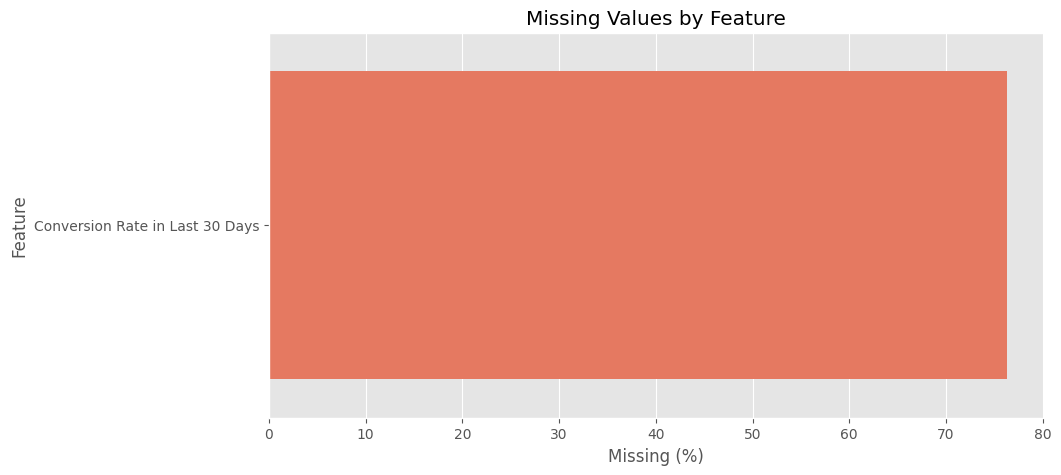

In [8]:
missing = missing[missing["Missing Values"] > 0]

if len(missing) > 0:

    plt.figure(figsize=(10,5))

    sns.barplot(
        data=missing.reset_index(),
        x="Missing (%)",
        y="index",
        palette="Reds_r"
    )

    plt.title("Missing Values by Feature")

    plt.ylabel("Feature")

    plt.show()

else:
    print("No missing values found.")

### Duplicate Records

In [9]:
duplicates = df.duplicated().sum()

print(f"Duplicate rows: {duplicates:,}")

print(f"Duplicate percentage: {duplicates/len(df)*100:.2f}%")

Duplicate rows: 0
Duplicate percentage: 0.00%


### Data Types

In [10]:
dtype_summary = (
    df.dtypes
    .astype(str)
    .value_counts()
    .rename_axis("Data Type")
    .reset_index(name="Count")
)

dtype_summary

,Data Type,Count
0,int64,3
1,object,3
2,float64,3


### Unique Values
This immediately tells us:

- IDs
- Binary columns
- Constant columns
- High-cardinality variables

In [11]:
unique = pd.DataFrame({
    "Unique Values": df.nunique()
})

unique.sort_values("Unique Values")

,Unique Values
Product Status,2
Seller Type,2
Category,15
Seller ID,188
Price Before Discount,292
Conversion Rate in Last 30 Days,339
Price After Discount,414
Product ID,2348
Variant ID,2999


### Numeric vs Categorical Columns

In [12]:
numerical_features = df.select_dtypes(include=np.number).columns.tolist()

categorical_features = df.select_dtypes(exclude=np.number).columns.tolist()

print(f"Numerical Features: {len(numerical_features)}")
print(f"Categorical Features: {len(categorical_features)}")

Numerical Features: 6
Categorical Features: 3


### Feature Summary

In [13]:
summary = pd.DataFrame({

    "Data Type": df.dtypes,

    "Missing": df.isna().sum(),

    "Unique": df.nunique(),

    "Sample Value": df.iloc[0]

})

summary

,Data Type,Missing,Unique,Sample Value
Variant ID,int64,0,2999,38832443
Product ID,int64,0,2348,10712965
Product Status,object,0,2,Active
Category,object,0,15,BT
Seller ID,int64,0,188,203163
Seller Type,object,0,2,Normal
Conversion Rate in Last 30 Days,float64,2288,339,NaN
Price Before Discount,float64,0,292,1215000.011057
Price After Discount,float64,0,414,445500.004054


### Business Data Audit

In [14]:
business_summary = {
    "Total Sellers": df["Seller ID"].nunique(),
    "Total Products": df["Product ID"].nunique(),
    "Total Categories": df["Category"].nunique(),
    "Seller Types": df["Seller Type"].nunique(),
    "Active Products": (df["Product Status"] == "Active").sum(),
    "Inactive Products": (df["Product Status"] != "Active").sum()
}

pd.DataFrame(
    business_summary.items(),
    columns=["Metric", "Value"]
)

,Metric,Value
0,Total Sellers,188
1,Total Products,2348
2,Total Categories,15
3,Seller Types,2
4,Active Products,2817
5,Inactive Products,182


## Data Quality Summary

Based on the initial assessment, we now have a clear understanding of the dataset quality.

Key observations include:

- Missing values
- Duplicate records
- Feature types
- Unique value distributions

These findings will guide the preprocessing and feature engineering steps before building the seller segmentation model.

# Exploratory Data Analysis (EDA)

The goal of this analysis is to better understand seller behavior before building the segmentation model.

This section explores:

- Seller activity
- Product characteristics
- Pricing behavior
- Product categories
- Conversion performance
- Relationships between numerical variables

The insights gained here will guide the feature engineering process used for seller segmentation.

### Seller Type Distribution

**Business Question:**


**What types of sellers exist in the marketplace?**


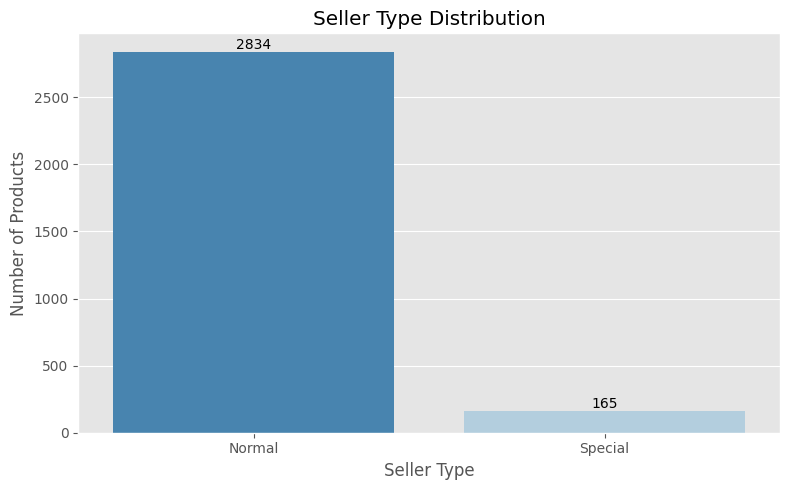

In [15]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x="Seller Type",
    order=df["Seller Type"].value_counts().index,
    palette="Blues_r"
)

plt.title("Seller Type Distribution")
plt.xlabel("Seller Type")
plt.ylabel("Number of Products")

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x()+p.get_width()/2, p.get_height()),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### Product Status Distribution
**Business Question:**

**How many products are currently active?**

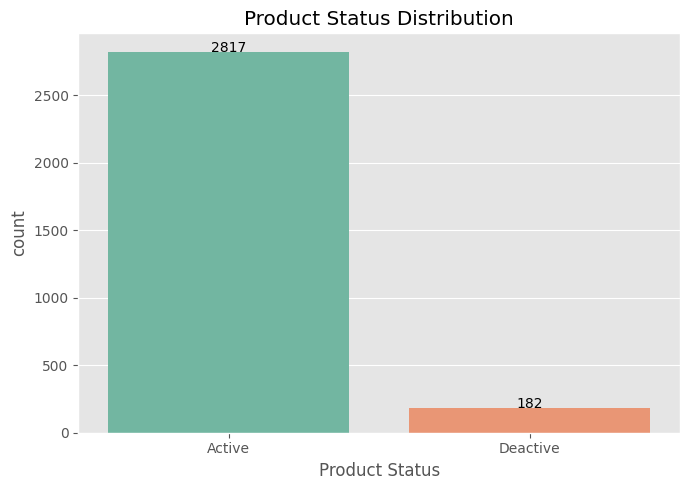

In [16]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=df,
    x="Product Status",
    order=df["Product Status"].value_counts().index,
    palette="Set2"
)

plt.title("Product Status Distribution")

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x()+p.get_width()/2,p.get_height()),
        ha="center"
    )

plt.tight_layout()
plt.show()

### Top Categories
**Business Question:**

**Which product categories dominate the marketplace?**

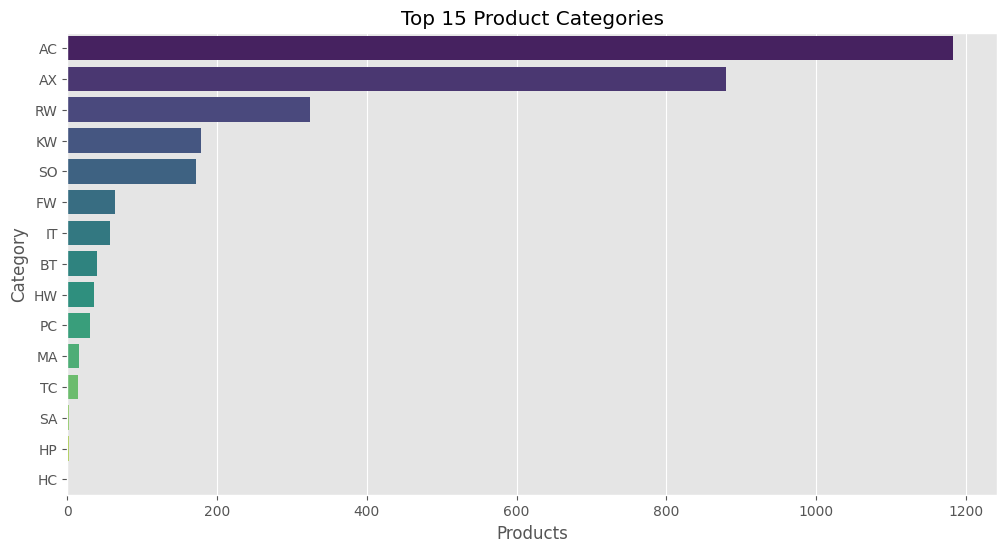

In [17]:
top_categories = df["Category"].value_counts().head(15)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_categories.values,
    y=top_categories.index,
    palette="viridis"
)

plt.title("Top 15 Product Categories")

plt.xlabel("Products")

plt.ylabel("Category")

plt.show()

### Products per Seller
**Business Question:**

**Do sellers usually sell only a few products or large catalogs?**

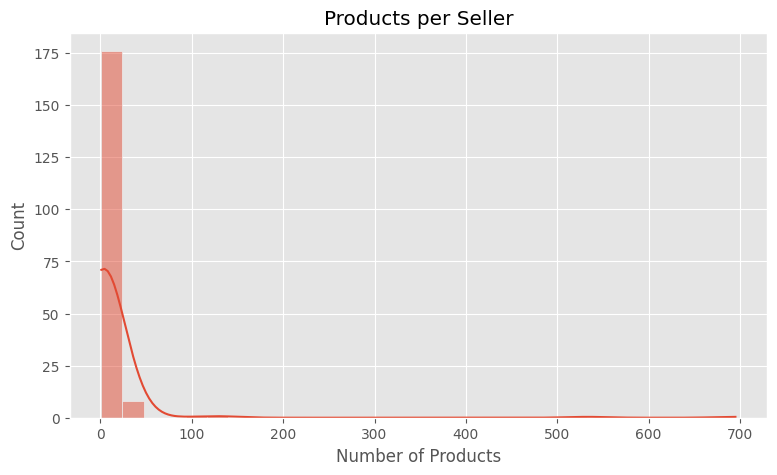

In [18]:
products_per_seller = (
    df.groupby("Seller ID")["Product ID"]
    .nunique()
)

plt.figure(figsize=(9,5))

sns.histplot(
    products_per_seller,
    bins=30,
    kde=True
)

plt.title("Products per Seller")

plt.xlabel("Number of Products")

plt.show()

### Conversion Rate Distribution
**Business Question:**

**How well do products convert?**

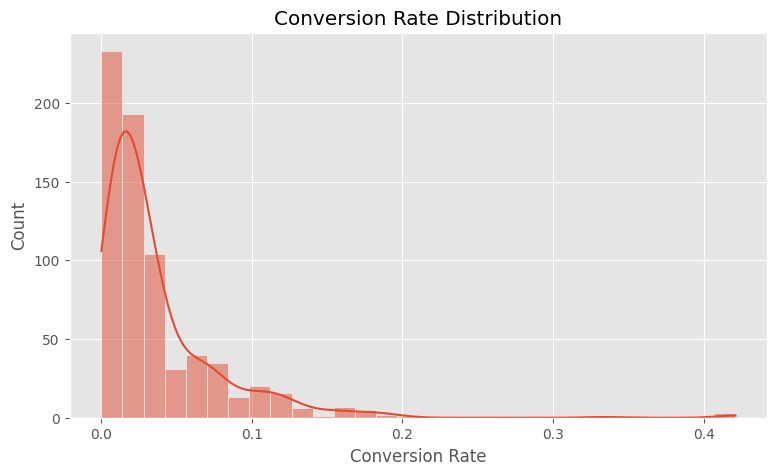

In [19]:
plt.figure(figsize=(9,5))

sns.histplot(
    df["Conversion Rate in Last 30 Days"],
    bins=30,
    kde=True
)

plt.title("Conversion Rate Distribution")

plt.xlabel("Conversion Rate")

plt.show()

### Price Distribution

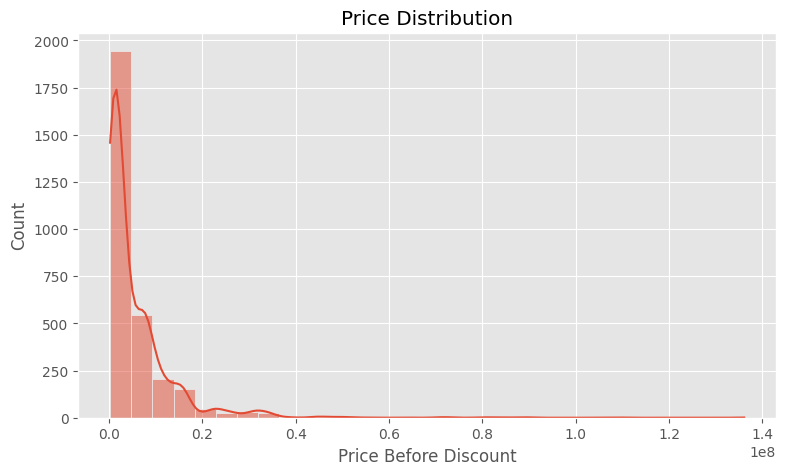

In [20]:
plt.figure(figsize=(9,5))

sns.histplot(
    df["Price Before Discount"],
    bins=30,
    kde=True
)

plt.title("Price Distribution")

plt.xlabel("Price Before Discount")

plt.show()

### Discount Analysis
Instead of only looking at prices, let's create a new business metric.

In [21]:
df["Discount (%)"] = (
    (df["Price Before Discount"] - df["Price After Discount"])
    / df["Price Before Discount"]
) * 100

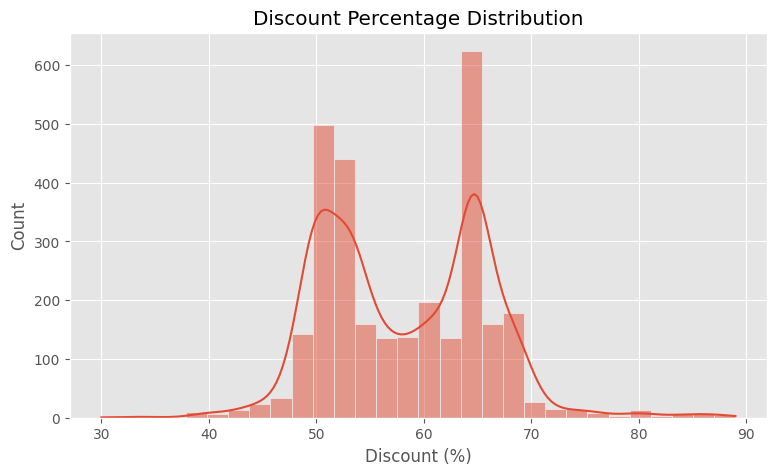

In [22]:
plt.figure(figsize=(9,5))

sns.histplot(
    df["Discount (%)"],
    bins=30,
    kde=True
)

plt.title("Discount Percentage Distribution")

plt.xlabel("Discount (%)")

plt.show()

### Correlation Heatmap
Now we inspect relationships between numerical variables.

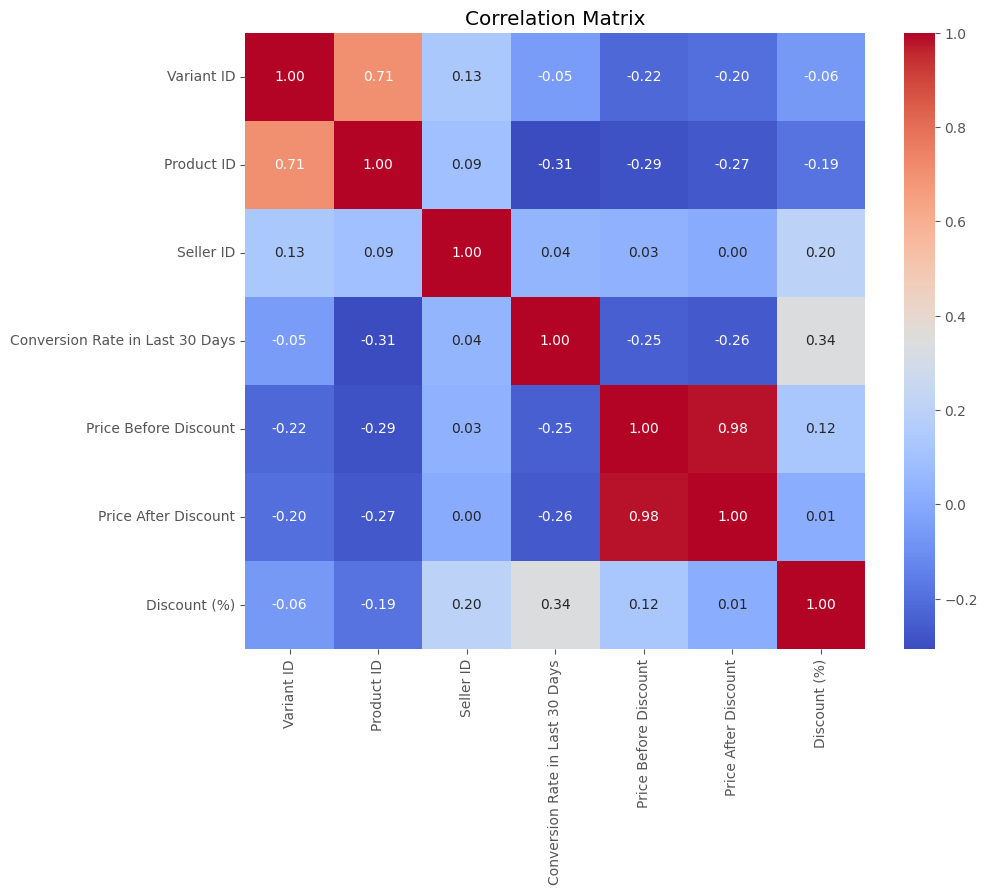

In [23]:
numeric_df = df.select_dtypes(include="number")

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

### Outlier Detection

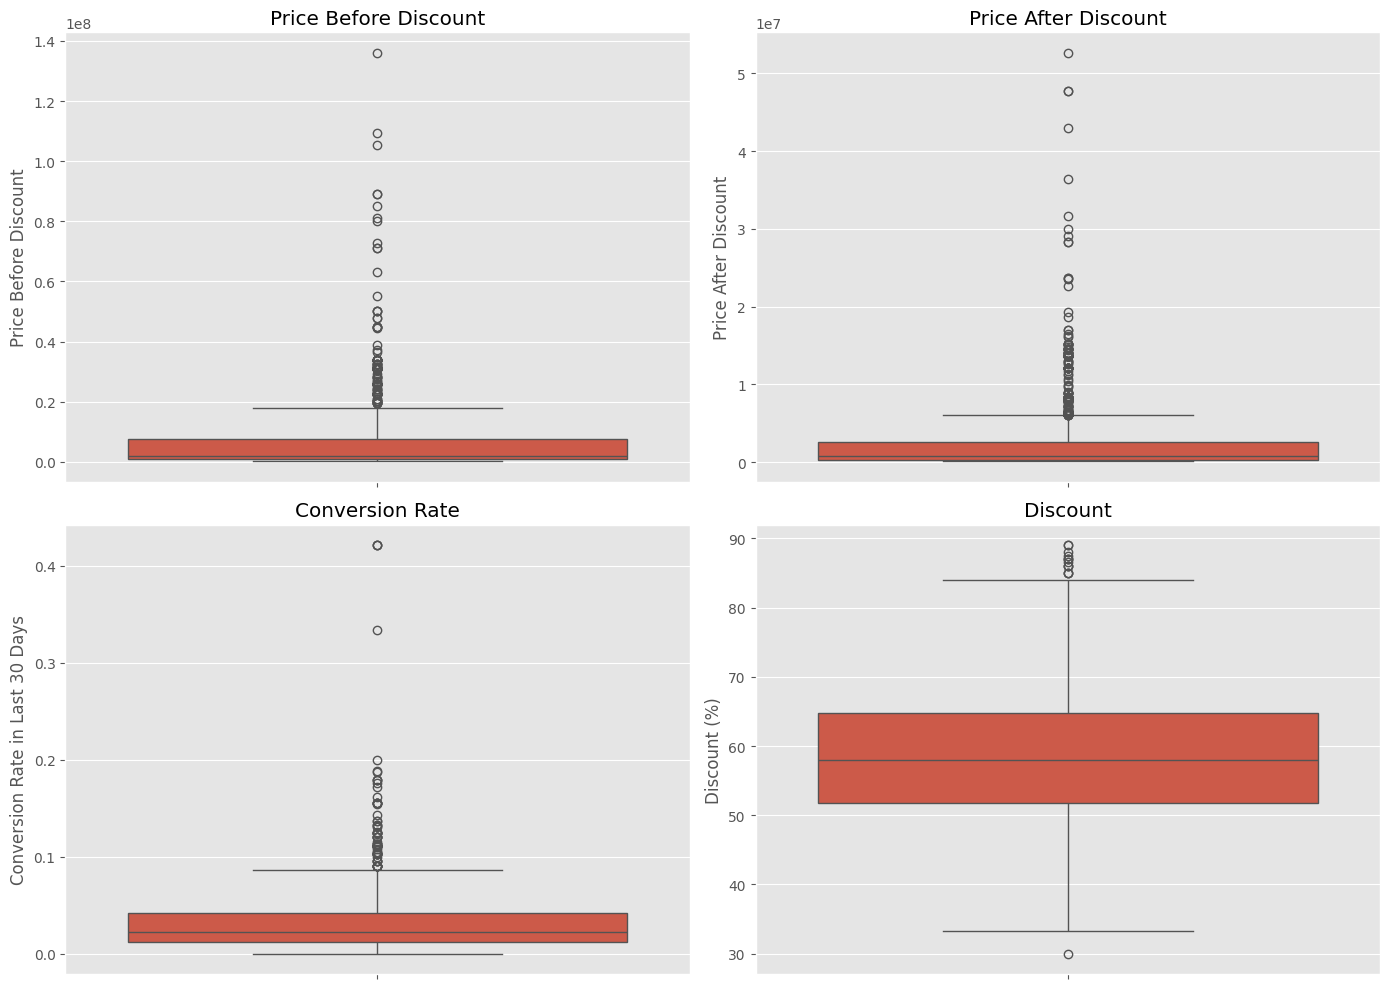

In [24]:
fig, axes = plt.subplots(2,2, figsize=(14,10))

sns.boxplot(
    y=df["Price Before Discount"],
    ax=axes[0,0]
)

axes[0,0].set_title("Price Before Discount")

sns.boxplot(
    y=df["Price After Discount"],
    ax=axes[0,1]
)

axes[0,1].set_title("Price After Discount")

sns.boxplot(
    y=df["Conversion Rate in Last 30 Days"],
    ax=axes[1,0]
)

axes[1,0].set_title("Conversion Rate")

sns.boxplot(
    y=df["Discount (%)"],
    ax=axes[1,1]
)

axes[1,1].set_title("Discount")

plt.tight_layout()

plt.show()

# Key Findings from the Exploratory Analysis

The exploratory analysis provides several important insights about seller behavior:

### Seller Activity
- Seller activity is not evenly distributed across the marketplace.
- Some sellers manage significantly larger product catalogs than others.

### Product Portfolio
- Product categories are highly concentrated, indicating that some categories dominate the marketplace.

### Pricing Strategy
- Product prices vary considerably across sellers.
- Discount strategies differ significantly between products.

### Conversion Performance
- Conversion rates are positively skewed, suggesting that only a subset of products achieves consistently high conversion.

### Implications for Seller Segmentation
These findings suggest that seller segmentation should incorporate multiple behavioral dimensions rather than relying on a single metric.

The next step is to engineer seller-level features that summarize these characteristics before applying clustering.

# Feature Engineering

The original dataset contains product-level information, while our objective is to segment **sellers**.

Therefore, the data must be aggregated so that each row represents a single seller.

The engineered features are designed to capture different aspects of seller behavior, including:

- Seller size
- Product activity
- Pricing strategy
- Sales performance
- Product diversity

These seller-level features will serve as the input for the clustering model.

### Discount Feature

In [25]:
df["Discount (%)"] = (
    (df["Price Before Discount"] - df["Price After Discount"])
    / df["Price Before Discount"]
) * 100

### Premium Product Threshold
Why?

Using the 75th percentile makes the definition of a "premium product" adapt to the dataset and avoids hard-coded thresholds.

In [26]:
premium_threshold = df["Price After Discount"].quantile(0.75)

premium_threshold

np.float64(2608200.0237346203)

### Premium Product Flag

In [27]:
df["Premium Product"] = (
    df["Price After Discount"] >= premium_threshold
).astype(int)

### Seller-Level Aggregation
Now we aggregate product-level data into seller-level features.

In [28]:
seller_features = (
    df.groupby("Seller ID")
      .agg(
          total_products=("Product ID", "nunique"),

          active_ratio=("Product Status",
                        lambda x: (x == "Active").mean()),

          avg_conversion_rate=("Conversion Rate in Last 30 Days", "mean"),

          avg_price=("Price After Discount", "mean"),

          avg_discount=("Discount (%)", "mean"),

          category_count=("Category", "nunique"),

          price_std=("Price After Discount", "std"),

          premium_product_ratio=("Premium Product", "mean")
      )
      .round(3)
      .reset_index()
)

### Handle Missing Values

In [29]:
seller_features["price_std"] = (
    seller_features["price_std"]
    .fillna(0)
)

### Seller Feature Dataset

In [30]:
seller_features.head()

,Seller ID,total_products,active_ratio,avg_conversion_rate,avg_price,avg_discount,category_count,price_std,premium_product_ratio
0,602,1,1.0,NaN,7.209000e+05,54.359,1,0.000,0.0
1,679,4,1.0,0.000,4.365900e+06,71.096,1,428611.716,1.0
2,1665,4,1.0,0.014,3.869269e+06,48.008,1,928108.481,1.0
3,4801,3,1.0,0.012,1.593675e+07,51.849,1,1566988.926,1.0
4,5799,5,1.0,NaN,3.402000e+05,44.000,1,0.000,0.0


### Summary Statistics

In [31]:
seller_features.describe().T

,count,mean,std,min,25%,50%,75%,max
Seller ID,188.0,5.354543e+05,3.770279e+05,602.000,170916.750,5.140560e+05,9.283098e+05,1.089196e+06
total_products,188.0,1.253191e+01,6.477236e+01,1.000,1.000,2.000000e+00,4.000000e+00,6.950000e+02
active_ratio,188.0,9.660691e-01,1.695909e-01,0.000,1.000,1.000000e+00,1.000000e+00,1.000000e+00
avg_conversion_rate,114.0,2.666667e-02,2.761578e-02,0.000,0.010,1.800000e-02,3.275000e-02,1.360000e-01
avg_price,188.0,3.105810e+06,5.253875e+06,111452.144,558900.005,1.607850e+06,3.397950e+06,5.265000e+07
avg_discount,188.0,5.601751e+01,7.599693e+00,33.333,51.000,5.482250e+01,6.000000e+01,8.000000e+01
category_count,188.0,1.228723e+00,5.719134e-01,1.000,1.000,1.000000e+00,1.000000e+00,5.000000e+00
price_std,188.0,7.003003e+05,2.209136e+06,0.000,0.000,0.000000e+00,3.051861e+05,2.039158e+07
premium_product_ratio,188.0,3.111755e-01,4.283999e-01,0.000,0.000,0.000000e+00,7.925000e-01,1.000000e+00


### Feature Correlation

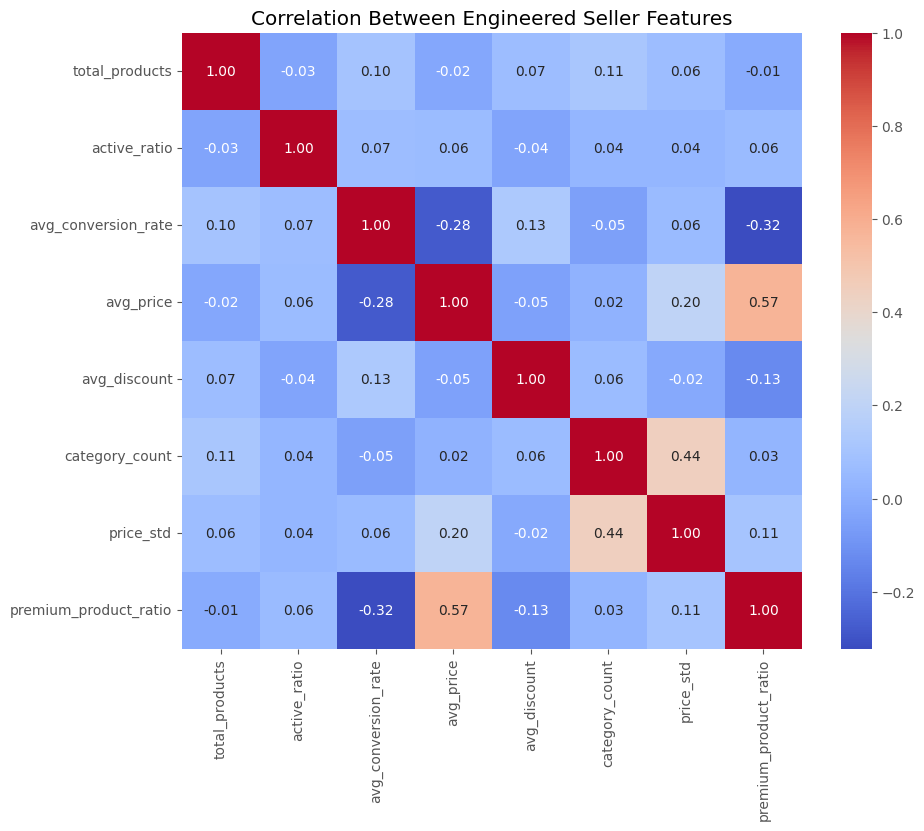

In [32]:
plt.figure(figsize=(10,8))

sns.heatmap(
    seller_features.drop(columns="Seller ID").corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Engineered Seller Features")

plt.show()

### Distribution of Engineered Features

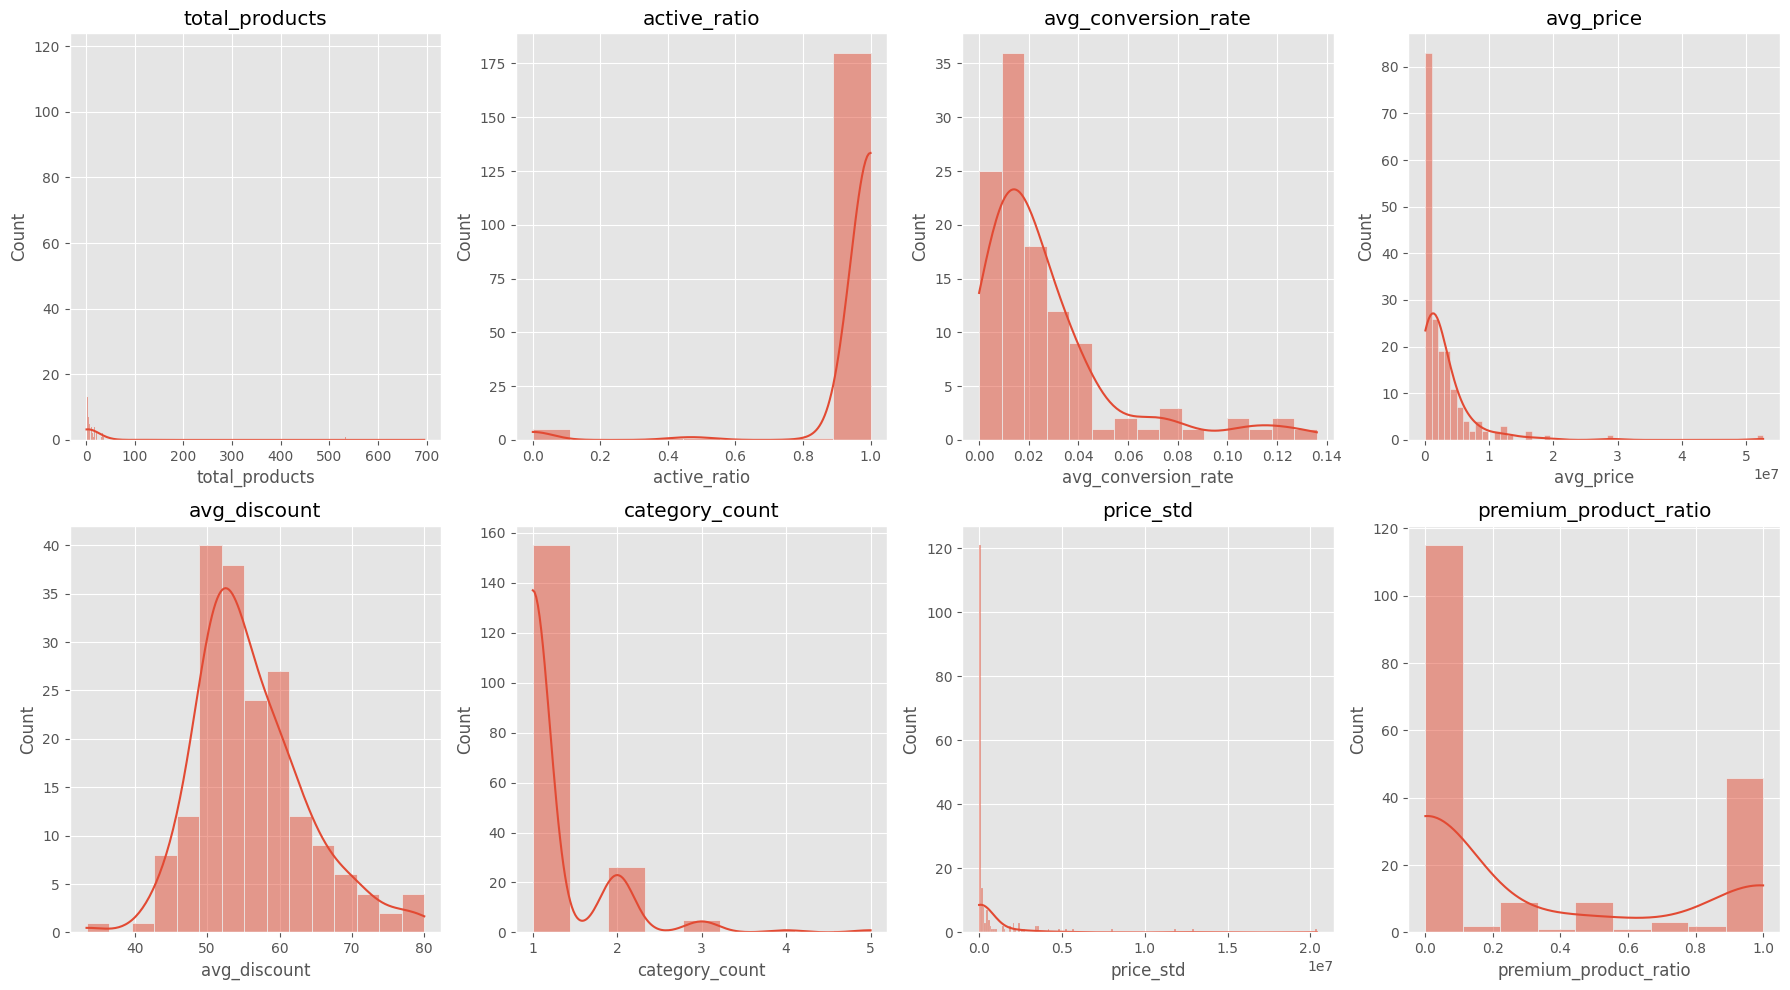

In [33]:
features = seller_features.drop(columns="Seller ID")

fig, axes = plt.subplots(2,4, figsize=(18,10))

for ax, column in zip(axes.flat, features.columns):

    sns.histplot(
        seller_features[column],
        kde=True,
        ax=ax
    )

    ax.set_title(column)

plt.tight_layout()

plt.show()

### Conversion Consistency

In [34]:
seller_features = (
    df.groupby("Seller ID")
      .agg(
          total_products=("Product ID", "nunique"),

          active_ratio=("Product Status",
                        lambda x: (x == "Active").mean()),

          avg_conversion_rate=("Conversion Rate in Last 30 Days", "mean"),

          conversion_std=("Conversion Rate in Last 30 Days", "std"),

          avg_price=("Price After Discount", "mean"),

          avg_discount=("Discount (%)", "mean"),

          category_count=("Category", "nunique"),

          price_std=("Price After Discount", "std"),

          premium_product_ratio=("Premium Product", "mean")
      )
      .reset_index()
)

In [35]:
seller_features.isna().sum()

Seller ID                  0
total_products             0
active_ratio               0
avg_conversion_rate       74
conversion_std           121
avg_price                  0
avg_discount               0
category_count             0
price_std                 73
premium_product_ratio      0
dtype: int64

In [36]:
seller_features["avg_conversion_rate"] = (
    seller_features["avg_conversion_rate"]
    .fillna(0)
)

### Fill Missing Values
Sellers with only one product won't have a standard deviation.

In [37]:
seller_features["conversion_std"] = (
    seller_features["conversion_std"]
    .fillna(0)
)

seller_features["price_std"] = (
    seller_features["price_std"]
    .fillna(0)
)

# Data Preprocessing

Before applying K-Means clustering, the engineered seller features must be prepared.

This stage includes:

- Removing non-informative columns
- Scaling numerical features
- Preparing the final feature matrix for clustering

Feature scaling is particularly important because K-Means relies on Euclidean distance. Without scaling, variables with larger numerical ranges could dominate the clustering process.

### Prepare Feature Matrix

In [38]:
seller_ids = seller_features["Seller ID"]

X = seller_features.drop(columns=["Seller ID"])

X.head()

,total_products,active_ratio,avg_conversion_rate,conversion_std,avg_price,avg_discount,category_count,price_std,premium_product_ratio
0,1,1.0,0.000000,0.000000,7.209000e+05,54.358974,1,0.000000e+00,0.0
1,4,1.0,0.000407,0.000328,4.365900e+06,71.095833,1,4.286117e+05,1.0
2,4,1.0,0.014350,0.012028,3.869269e+06,48.007611,1,9.281085e+05,1.0
3,3,1.0,0.011527,0.000000,1.593675e+07,51.849101,1,1.566989e+06,1.0
4,5,1.0,0.000000,0.000000,3.402000e+05,44.000000,1,0.000000e+00,0.0


### Feature Overview

In [39]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
total_products,188.0,1.253191e+01,6.477236e+01,1.000000,1.000000,2.000000e+00,4.000000e+00,6.950000e+02
active_ratio,188.0,9.660699e-01,1.695982e-01,0.000000,1.000000,1.000000e+00,1.000000e+00,1.000000e+00
avg_conversion_rate,188.0,1.615786e-02,2.513459e-02,0.000000,0.000000,8.298432e-03,2.127125e-02,1.356624e-01
conversion_std,188.0,4.971796e-03,1.364536e-02,0.000000,0.000000,0.000000e+00,1.311582e-04,9.971392e-02
avg_price,188.0,3.105810e+06,5.253875e+06,111452.143871,558900.005086,1.607850e+06,3.397950e+06,5.265000e+07
avg_discount,188.0,5.601750e+01,7.599723e+00,33.333333,51.000000,5.482255e+01,6.000000e+01,8.000000e+01
category_count,188.0,1.228723e+00,5.719134e-01,1.000000,1.000000,1.000000e+00,1.000000e+00,5.000000e+00
price_std,188.0,7.003003e+05,2.209136e+06,0.000000,0.000000,0.000000e+00,3.051861e+05,2.039158e+07
premium_product_ratio,188.0,3.111838e-01,4.284041e-01,0.000000,0.000000,0.000000e+00,7.924107e-01,1.000000e+00


### Standardization

In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns,
    index=X.index
)

X_scaled.head()

,total_products,active_ratio,avg_conversion_rate,conversion_std,avg_price,avg_discount,category_count,price_std,premium_product_ratio
0,-0.178513,0.200596,-0.644570,-0.365331,-0.455146,-0.218817,-0.400995,-0.317848,-0.728319
1,-0.132073,0.200596,-0.628334,-0.341226,0.240481,1.989362,-0.400995,-0.123312,1.612159
2,-0.132073,0.200596,-0.072104,0.518525,0.145701,-1.056785,-0.400995,0.103396,1.612159
3,-0.147553,0.200596,-0.184735,-0.365331,2.448707,-0.549958,-0.400995,0.393368,1.612159
4,-0.116593,0.200596,-0.644570,-0.365331,-0.527800,-1.585530,-0.400995,-0.317848,-0.728319


### Verify Scaling

In [41]:
X_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
total_products,188.0,1.889741e-17,1.00267,-0.178513,-0.178513,-0.163033,-0.132073,10.564543
active_ratio,188.0,-8.787297e-16,1.00267,-5.711438,0.200596,0.200596,0.200596,0.200596
avg_conversion_rate,188.0,5.669224e-17,1.00267,-0.644570,-0.644570,-0.313529,0.203983,4.767283
conversion_std,188.0,3.779483e-17,1.00267,-0.365331,-0.365331,-0.365331,-0.355693,6.961713
avg_price,188.0,2.834612e-17,1.00267,-0.571455,-0.486062,-0.285877,0.055753,9.455209
avg_discount,188.0,-5.999929e-16,1.00267,-2.992838,-0.661984,-0.157656,0.525432,3.164134
category_count,188.0,-1.322819e-16,1.00267,-0.400995,-0.400995,-0.400995,-0.400995,6.611747
price_std,188.0,-9.448707e-18,1.00267,-0.317848,-0.317848,-0.317848,-0.179332,8.937367
premium_product_ratio,188.0,-4.251918e-17,1.00267,-0.728319,-0.728319,-0.728319,1.126301,1.612159


### Distribution After Scaling

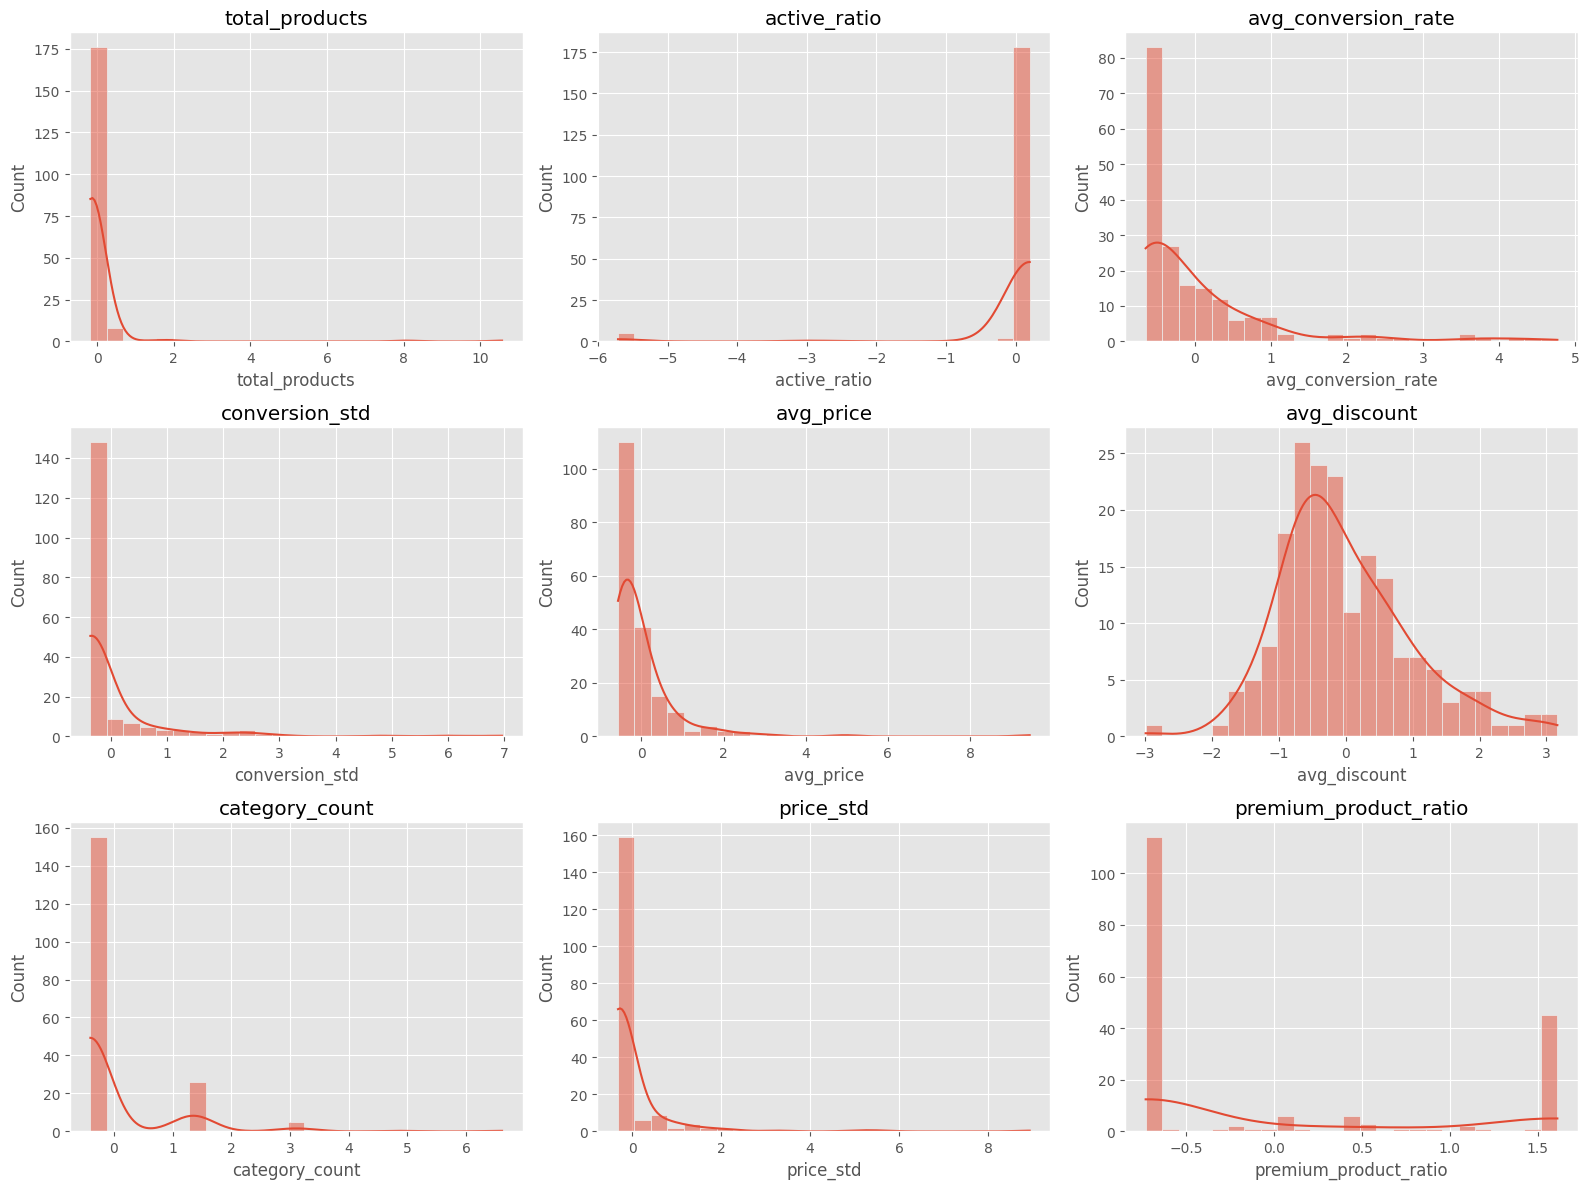

In [42]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))

for ax, feature in zip(axes.flat, X_scaled.columns):

    sns.histplot(
        X_scaled[feature],
        bins=25,
        kde=True,
        ax=ax
    )

    ax.set_title(feature)

plt.tight_layout()
plt.show()

# Determining the Optimal Number of Clusters

Choosing the appropriate number of clusters is a critical step in K-Means clustering.

To identify a suitable value of **K**, two complementary evaluation methods are used:

- **Elbow Method**: Measures the within-cluster sum of squares (WCSS).
- **Silhouette Score**: Evaluates cluster separation and cohesion.

Using both methods provides a more reliable basis for selecting the optimal number of clusters.

### Elbow Method

In [43]:
inertia = []

K = range(2,11)

for k in K:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    inertia.append(model.inertia_)

### Elbow Plot

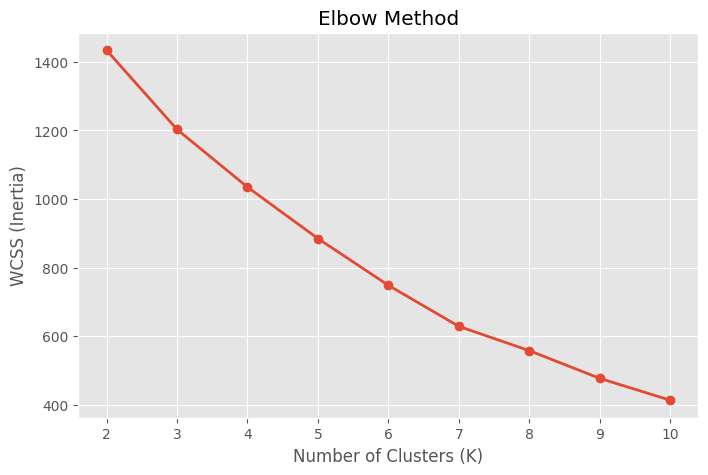

In [44]:
plt.figure(figsize=(8,5))

plt.plot(
    K,
    inertia,
    marker="o",
    linewidth=2
)

plt.xticks(K)

plt.xlabel("Number of Clusters (K)")

plt.ylabel("WCSS (Inertia)")

plt.title("Elbow Method")

plt.grid(True)

plt.show()

### Silhouette Scores

In [45]:
silhouette_scores = []

for k in K:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    silhouette_scores.append(score)

### Silhouette Plot

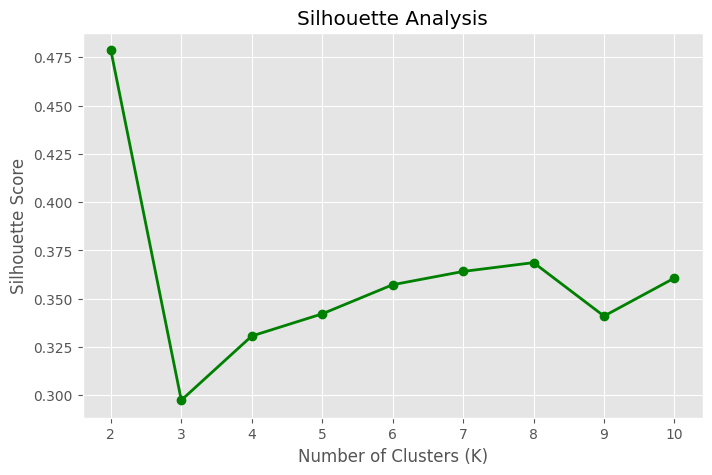

In [46]:
plt.figure(figsize=(8,5))

plt.plot(
    K,
    silhouette_scores,
    marker="o",
    linewidth=2,
    color="green"
)

plt.xticks(K)

plt.xlabel("Number of Clusters (K)")

plt.ylabel("Silhouette Score")

plt.title("Silhouette Analysis")

plt.grid(True)

plt.show()

### Compare Results

In [47]:
evaluation = pd.DataFrame({
    "K": list(K),
    "Inertia": inertia,
    "Silhouette Score": np.round(silhouette_scores,3)
})

evaluation

,K,Inertia,Silhouette Score
0,2,1433.834619,0.479
1,3,1202.850040,0.297
2,4,1034.654900,0.331
3,5,884.619695,0.342
4,6,748.210746,0.357
5,7,628.502761,0.364
6,8,557.779992,0.369
7,9,476.885324,0.341
8,10,413.160250,0.361


In [48]:
best_k = evaluation.loc[
    evaluation["Silhouette Score"].idxmax(),
    "K"
]

print(f"Best K according to Silhouette Score: {best_k}")

Best K according to Silhouette Score: 2


# Selecting the Optimal Number of Clusters

Based on the Elbow Method and Silhouette Analysis, the most appropriate number of clusters is selected.

The Elbow Method identifies the point where additional clusters provide diminishing improvements in compactness.

The Silhouette Score evaluates how well-separated the clusters are, with higher values indicating better-defined clusters.

Using both metrics together helps balance cluster quality and interpretability.

In [49]:
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

results = []

for k in range(2, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    results.append({
        "K": k,
        "Silhouette": silhouette_score(X_scaled, labels),
        "Davies-Bouldin": davies_bouldin_score(X_scaled, labels),
        "Calinski-Harabasz": calinski_harabasz_score(X_scaled, labels)
    })

evaluation = pd.DataFrame(results)

evaluation.round(3)

,K,Silhouette,Davies-Bouldin,Calinski-Harabasz
0,2,0.479,1.773,33.490
1,3,0.297,1.570,37.616
2,4,0.331,1.384,38.967
3,5,0.342,1.082,41.755
4,6,0.357,1.050,45.915
5,7,0.364,0.927,51.045
6,8,0.369,0.894,52.289
7,9,0.341,0.860,57.012
8,10,0.361,0.823,61.217


In [50]:
seller_features_k = seller_features.copy()
for k in [5, 6, 7, 8]:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    seller_features_k[f"cluster_{k}"] = model.fit_predict(X_scaled)

In [52]:
seller_features_k.groupby("cluster_5").mean().round(2)

,Seller ID,total_products,active_ratio,avg_conversion_rate,conversion_std,avg_price,avg_discount,category_count,price_std,premium_product_ratio,cluster_6,cluster_7,cluster_8
cluster_5,,,,,,,,,,,,,
0,667907.08,21.23,1.00,0.08,0.04,1467791.96,58.09,1.46,1510774.31,0.13,1.23,2.92,2.23
1,448243.41,5.66,1.00,0.01,0.00,7286480.52,54.97,1.33,1547399.85,0.87,2.62,0.41,2.62
2,575562.29,21.00,0.13,0.02,0.01,1447535.23,57.39,1.14,393904.26,0.18,4.00,6.00,6.00
3,559556.61,3.43,1.00,0.01,0.00,998330.81,56.18,1.14,106296.34,0.02,0.26,1.88,1.68
4,928692.00,614.00,1.00,0.04,0.04,2689129.21,60.83,1.50,1853279.35,0.32,5.00,5.00,4.00


In [54]:
seller_features_k.groupby("cluster_6").mean().round(2)

,Seller ID,total_products,active_ratio,avg_conversion_rate,conversion_std,avg_price,avg_discount,category_count,price_std,premium_product_ratio,cluster_5,cluster_7,cluster_8
cluster_6,,,,,,,,,,,,,
0,533606.04,2.77,1.00,0.01,0.00,1094808.70,55.83,1.00,202446.74,0.03,2.92,2.00,1.93
1,601037.73,11.64,1.00,0.09,0.04,702177.84,58.27,1.18,392741.43,0.05,0.27,2.91,2.09
2,633951.33,15.19,1.00,0.02,0.01,3018280.25,58.12,2.37,2763399.81,0.30,1.85,1.41,0.78
3,442574.11,3.91,1.00,0.01,0.00,8155586.80,54.21,1.04,587569.18,0.98,1.00,0.00,3.00
4,575562.29,21.00,0.13,0.02,0.01,1447535.23,57.39,1.14,393904.26,0.18,2.00,6.00,6.00
5,928692.00,614.00,1.00,0.04,0.04,2689129.21,60.83,1.50,1853279.35,0.32,4.00,5.00,4.00


In [53]:
seller_features_k.groupby("cluster_7").mean().round(2)

,Seller ID,total_products,active_ratio,avg_conversion_rate,conversion_std,avg_price,avg_discount,category_count,price_std,premium_product_ratio,cluster_5,cluster_6,cluster_8
cluster_7,,,,,,,,,,,,,
0,442574.11,3.91,1.00,0.01,0.00,8155586.80,54.21,1.04,587569.18,0.98,1.00,3.00,3.00
1,610719.70,15.26,1.00,0.01,0.00,2193001.39,58.79,2.30,1194023.66,0.29,2.09,2.00,0.00
2,533933.29,2.79,1.00,0.01,0.00,1087538.81,55.77,1.00,200337.92,0.03,2.92,0.01,1.92
3,600057.64,12.45,1.00,0.09,0.04,1029544.08,58.65,1.27,576812.11,0.12,0.00,1.09,2.00
4,838630.67,15.00,1.00,0.05,0.01,9018868.78,54.13,3.00,15041491.13,0.28,0.67,2.00,7.00
5,928692.00,614.00,1.00,0.04,0.04,2689129.21,60.83,1.50,1853279.35,0.32,4.00,5.00,4.00
6,575562.29,21.00,0.13,0.02,0.01,1447535.23,57.39,1.14,393904.26,0.18,2.00,4.00,6.00


In [55]:
seller_features_k.groupby("cluster_8").mean().round(2)

,Seller ID,total_products,active_ratio,avg_conversion_rate,conversion_std,avg_price,avg_discount,category_count,price_std,premium_product_ratio,cluster_5,cluster_6,cluster_7
cluster_8,,,,,,,,,,,,,
0,608366.42,15.21,1.00,0.01,0.01,2268206.69,58.62,2.29,1228638.40,0.31,2.00,2.00,1.08
1,583477.53,8.07,1.00,0.06,0.02,913348.65,53.07,1.13,289213.96,0.04,1.60,0.53,2.47
2,531469.18,2.35,1.00,0.01,0.00,1097765.12,56.21,1.00,208254.42,0.03,2.91,0.00,2.00
3,442574.11,3.91,1.00,0.01,0.00,8155586.80,54.21,1.04,587569.18,0.98,1.00,3.00,0.00
4,928692.00,614.00,1.00,0.04,0.04,2689129.21,60.83,1.50,1853279.35,0.32,4.00,5.00,5.00
5,594179.33,21.00,1.00,0.12,0.09,475740.85,67.55,1.00,295999.09,0.01,0.00,1.00,3.00
6,575562.29,21.00,0.13,0.02,0.01,1447535.23,57.39,1.14,393904.26,0.18,2.00,4.00,6.00
7,838630.67,15.00,1.00,0.05,0.01,9018868.78,54.13,3.00,15041491.13,0.28,0.67,2.00,4.00


# Selecting the Final Number of Clusters

Several clustering evaluation metrics were used to determine an appropriate number of clusters, including the Elbow Method, Silhouette Score, Davies–Bouldin Index, and Calinski–Harabasz Index.

Although the Silhouette Score reached its highest value at **K = 2**, this solution produced only two broad seller groups, which limits the usefulness of the segmentation from a business perspective.

As the number of clusters increased, both the Davies–Bouldin Index improved (lower values) and the Calinski–Harabasz Index increased (higher values), indicating that additional structure exists within the data.

After comparing the evaluation metrics and considering the business objective of identifying meaningful seller profiles, **K = 5** was selected.

This choice provides a balance between statistical performance and business interpretability, allowing the marketplace to distinguish between multiple seller behaviors rather than simply separating sellers into high- and low-performing groups.

# K-Means Clustering

After selecting the optimal number of clusters, the K-Means algorithm is trained on the standardized seller features.

Each seller is assigned to one of five clusters based on similarities across multiple behavioral and operational characteristics.

The resulting clusters will be analyzed to identify meaningful seller profiles.

### Train the Model

In [56]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

seller_features["Cluster"] = kmeans.fit_predict(X_scaled)

### Cluster Sizes

In [57]:
cluster_sizes = (
    seller_features["Cluster"]
    .value_counts()
    .sort_index()
    .rename_axis("Cluster")
    .reset_index(name="Sellers")
)

cluster_sizes

,Cluster,Sellers
0,0,13
1,1,61
2,2,7
3,3,105
4,4,2


### Visualize Cluster Sizes

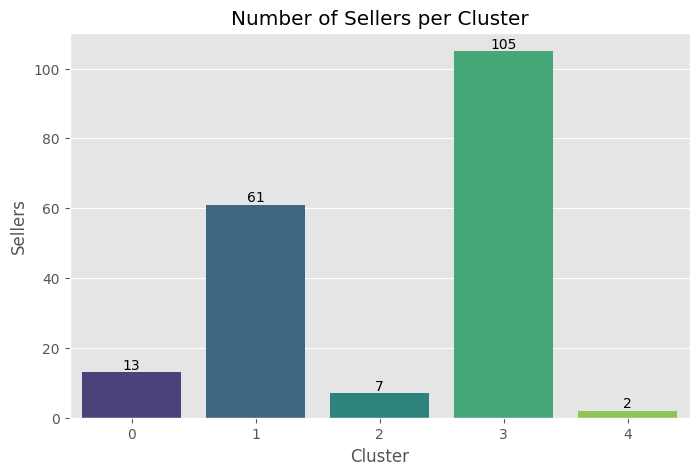

In [58]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=cluster_sizes,
    x="Cluster",
    y="Sellers",
    palette="viridis"
)

plt.title("Number of Sellers per Cluster")

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x()+p.get_width()/2,p.get_height()),
        ha="center",
        va="bottom"
    )

plt.show()

# Cluster Profiling

To understand the characteristics of each cluster, we calculate the average value of every engineered feature.

This enables us to identify the behavioral patterns that distinguish one seller group from another.

### Cluster Profile Table

In [59]:
cluster_profile = (
    seller_features
    .groupby("Cluster")
    .mean(numeric_only=True)
    .round(2)
)

cluster_profile

,Seller ID,total_products,active_ratio,avg_conversion_rate,conversion_std,avg_price,avg_discount,category_count,price_std,premium_product_ratio
Cluster,,,,,,,,,,
0,667907.08,21.23,1.00,0.08,0.04,1467791.96,58.09,1.46,1510774.31,0.13
1,448243.41,5.66,1.00,0.01,0.00,7286480.52,54.97,1.33,1547399.85,0.87
2,575562.29,21.00,0.13,0.02,0.01,1447535.23,57.39,1.14,393904.26,0.18
3,559556.61,3.43,1.00,0.01,0.00,998330.81,56.18,1.14,106296.34,0.02
4,928692.00,614.00,1.00,0.04,0.04,2689129.21,60.83,1.50,1853279.35,0.32


### Heatmap

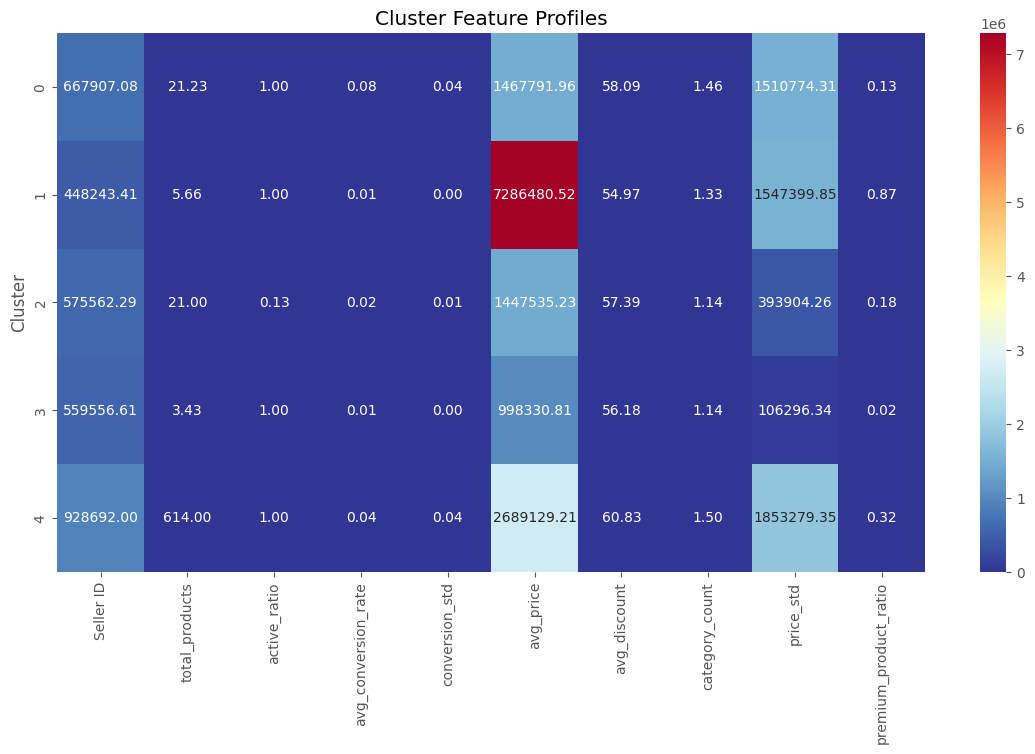

In [60]:
plt.figure(figsize=(14,7))

sns.heatmap(
    cluster_profile,
    annot=True,
    cmap="RdYlBu_r",
    fmt=".2f"
)

plt.title("Cluster Feature Profiles")

plt.show()

### Feature Comparison

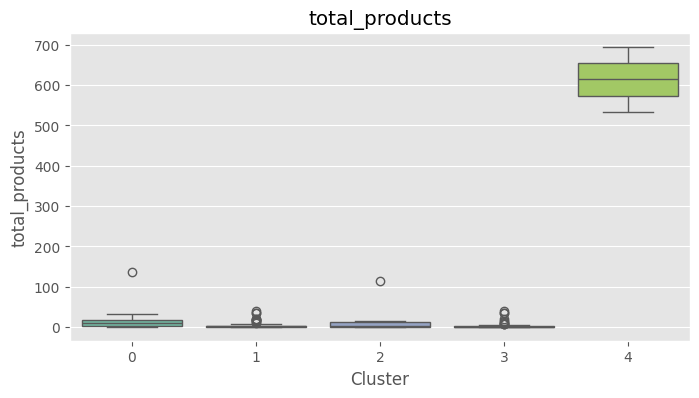

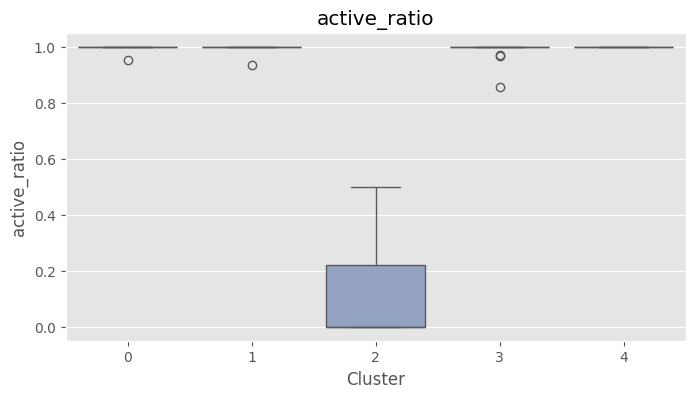

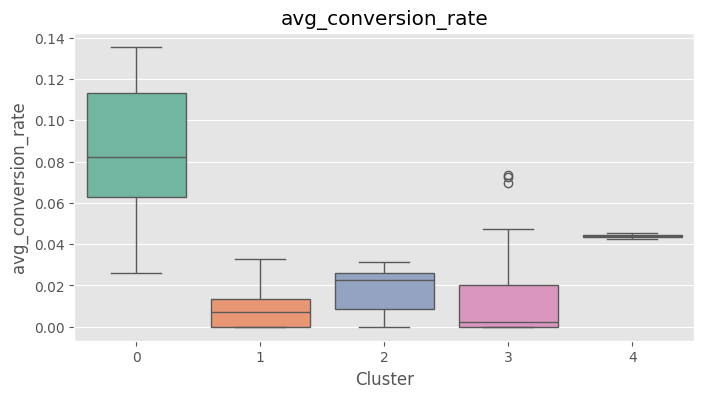

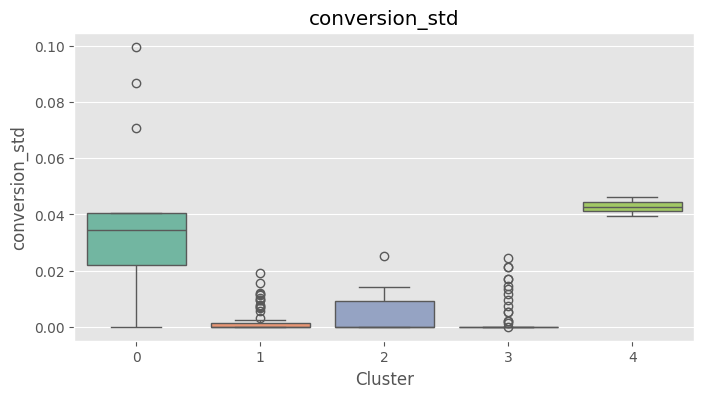

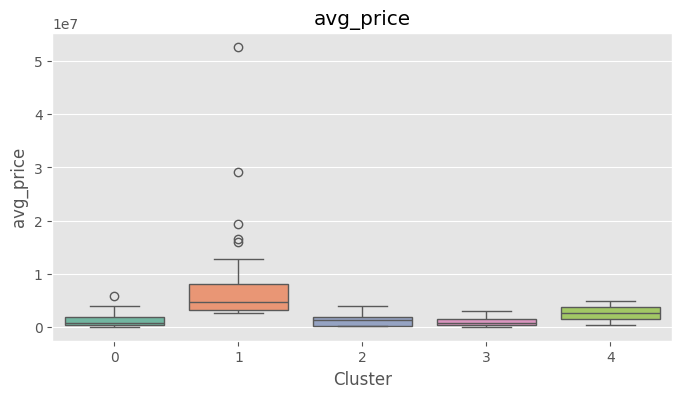

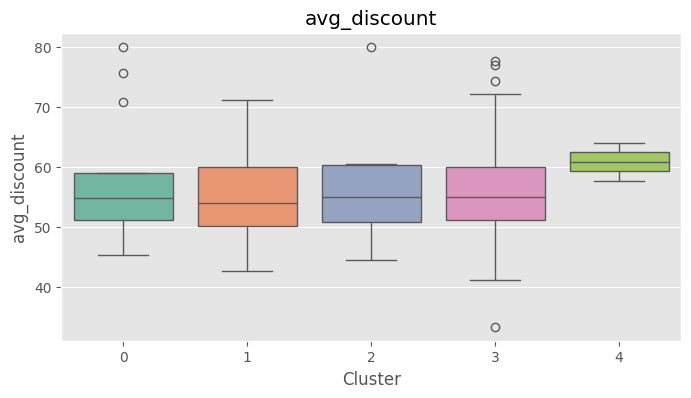

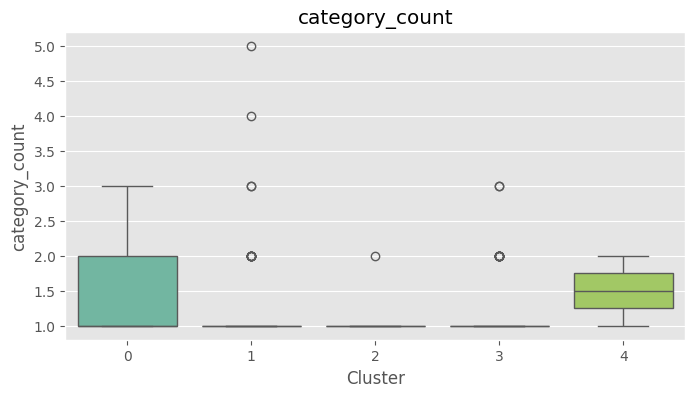

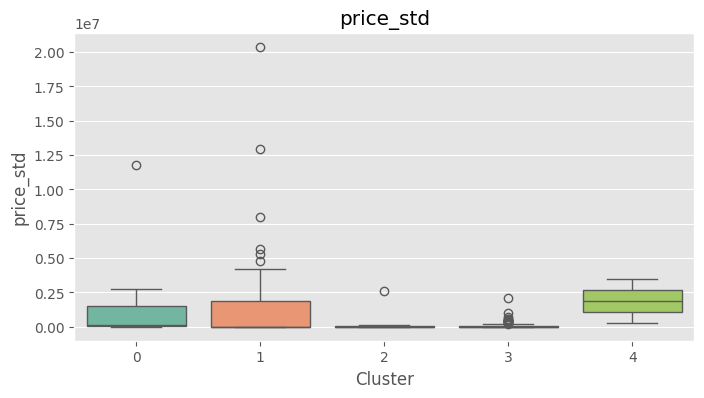

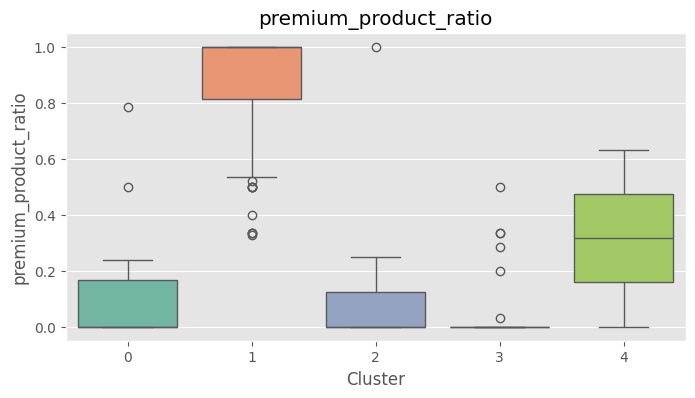

In [61]:
features = seller_features.drop(columns=["Seller ID","Cluster"]).columns

for feature in features:

    plt.figure(figsize=(8,4))

    sns.boxplot(
        data=seller_features,
        x="Cluster",
        y=feature,
        palette="Set2"
    )

    plt.title(feature)

    plt.show()

### PCA Visualization

In [62]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

components = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": components[:,0],
    "PC2": components[:,1],
    "Cluster": seller_features["Cluster"]
})

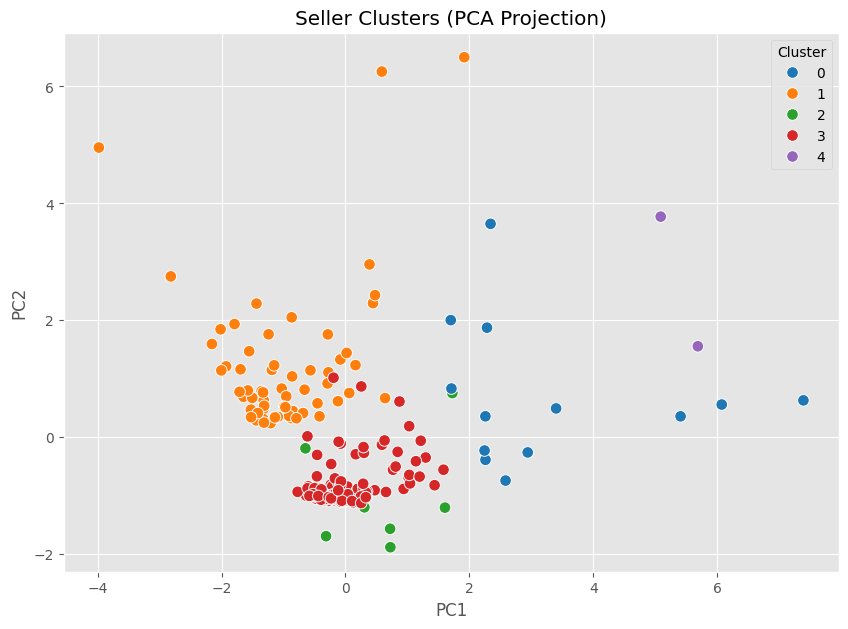

In [63]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="tab10",
    s=70
)

plt.title("Seller Clusters (PCA Projection)")

plt.show()

### Cluster Summary

In [64]:
cluster_summary = seller_features.groupby("Cluster").agg({

    "total_products":"mean",

    "active_ratio":"mean",

    "avg_conversion_rate":"mean",

    "avg_price":"mean",

    "avg_discount":"mean",

    "category_count":"mean"

}).round(2)

cluster_summary

,total_products,active_ratio,avg_conversion_rate,avg_price,avg_discount,category_count
Cluster,,,,,,
0,21.23,1.00,0.08,1467791.96,58.09,1.46
1,5.66,1.00,0.01,7286480.52,54.97,1.33
2,21.00,0.13,0.02,1447535.23,57.39,1.14
3,3.43,1.00,0.01,998330.81,56.18,1.14
4,614.00,1.00,0.04,2689129.21,60.83,1.50


### My interpretation

**Cluster 4 — Enterprise Sellers ⭐⭐⭐⭐⭐**

Products : Extremely High

Activity : High

Conversion : Good

Price : High

Categories : Highest

These sellers dominate the marketplace.

**Cluster 0 — High-Performing Sellers ⭐⭐⭐⭐**

Products : Medium

Conversion : Highest

Active : 100%

These sellers don't have huge catalogs, but they sell efficiently.

**Cluster 1 — Premium Sellers ⭐⭐⭐⭐**

Products : Few

Highest average price

Low conversion

These sellers specialize in expensive products.
High price naturally leads to lower conversion.

**Cluster 2 — Inactive Sellers ⭐⭐⭐**

Only 13% active products

Medium catalog

Poor conversion

This one is very obvious.
These sellers appear to have many inactive listings.

**Cluster 3 — Small Sellers ⭐⭐⭐**
Very few products

Low prices

Low conversion

These are likely new or very small merchants.

### Final Cluster Names

In [65]:
cluster_names = {
    0: "High-Performing Sellers",
    1: "Premium Sellers",
    2: "Inactive Sellers",
    3: "Emerging Sellers",
    4: "Enterprise Sellers"
}

In [66]:
seller_features["Seller Segment"] = (
    seller_features["Cluster"]
    .map(cluster_names)
)

### Visualize the segments

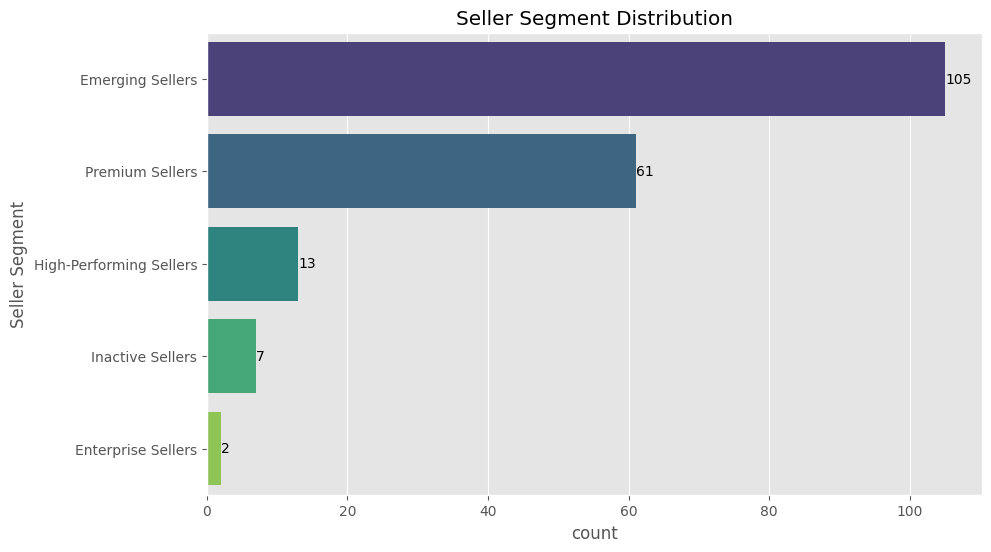

In [67]:
plt.figure(figsize=(10,6))

ax = sns.countplot(
    data=seller_features,
    y="Seller Segment",
    order=seller_features["Seller Segment"].value_counts().index,
    palette="viridis"
)

plt.title("Seller Segment Distribution")

for p in ax.patches:
    ax.annotate(
        f"{int(p.get_width())}",
        (p.get_width(), p.get_y()+p.get_height()/2),
        ha="left",
        va="center"
    )

plt.show()

In [68]:
seller_features.head()

,Seller ID,total_products,active_ratio,avg_conversion_rate,conversion_std,avg_price,avg_discount,category_count,price_std,premium_product_ratio,Cluster,Seller Segment
0,602,1,1.0,0.000000,0.000000,7.209000e+05,54.358974,1,0.000000e+00,0.0,3,Emerging Sellers
1,679,4,1.0,0.000407,0.000328,4.365900e+06,71.095833,1,4.286117e+05,1.0,1,Premium Sellers
2,1665,4,1.0,0.014350,0.012028,3.869269e+06,48.007611,1,9.281085e+05,1.0,1,Premium Sellers
3,4801,3,1.0,0.011527,0.000000,1.593675e+07,51.849101,1,1.566989e+06,1.0,1,Premium Sellers
4,5799,5,1.0,0.000000,0.000000,3.402000e+05,44.000000,1,0.000000e+00,0.0,3,Emerging Sellers


In [72]:
seller_df = seller_features[['Seller ID', 'Cluster', 'Seller Segment']]
seller_df.head()

,Seller ID,Cluster,Seller Segment
0,602,3,Emerging Sellers
1,679,1,Premium Sellers
2,1665,1,Premium Sellers
3,4801,1,Premium Sellers
4,5799,3,Emerging Sellers


### Save Dataframe into a CSV

In [73]:
seller_df.to_csv("../data/seller_segments.csv")